# Phase 5: Policy Gradient Theorem (Air Quality RL)

**MDP Formulation:**
- **State:** Past 24 hours of meteorological data (window of 24 consecutive rows, all features)
- **Action:** $a \in \{0, 1\}$ — 0 = Purifier OFF, 1 = Purifier ON
- **Reward:**
  - $R = -0.1$ if $a = 1$ (energy cost)
  - $R = -10.0$ if $a = 0$ **and** next-step PM2.5 > 150 (health penalty)
  - $R = 0.0$ otherwise

**Q5.13:** Implement REINFORCE (Monte Carlo Policy Gradient) from scratch.  
Build a policy network $\pi_\theta(a|s)$ outputting P(ON | s).  
Simulate trajectories through the training time-series.  
Update $\theta$ using the log-derivative trick.  
Plot total episodic return over 500 episodes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading & Chronological Split (70% Train)

In [2]:
CSV_PATH = '../Datasets/delhi_aqi_dataset/delhi_aqi.csv'
df = pd.read_csv(CSV_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

FEATURE_COLS = ['co', 'no', 'no2', 'o3', 'so2', 'pm10', 'nh3']
TARGET_COL   = 'pm2_5'

X_all   = df[FEATURE_COLS].values    # meteorological features
pm25_all = df[TARGET_COL].values     # PM2.5 values (for reward)

n       = len(X_all)
n_train = int(0.70 * n)

X_train   = X_all[:n_train]
pm25_train = pm25_all[:n_train]

print(f"Total rows: {n}  |  Train rows: {n_train}")
print(f"Features: {FEATURE_COLS}")

Total rows: 18776  |  Train rows: 13143
Features: ['co', 'no', 'no2', 'o3', 'so2', 'pm10', 'nh3']


## Environment & Policy Network

In [3]:
# ── Environment ────────────────────────────────────────────────────────────────
WINDOW = 24  # state = past 24 hours of meteorological data

def get_state(t, X):
    """Return flattened 24-hour window ending at time t (inclusive)."""
    return X[t - WINDOW + 1 : t + 1].flatten()  # shape: (WINDOW * n_feats,)


def get_reward(action, pm25_next):
    """Reward function as defined in the MDP."""
    if action == 1:
        return -0.1           # energy cost
    elif pm25_next > 150:
        return -10.0          # health penalty
    else:
        return 0.0


# ── Policy Network (1-hidden-layer MLP with NumPy) ─────────────────────────────
# Architecture: state_dim → H → 1 sigmoid → P(ON)
STATE_DIM = WINDOW * len(FEATURE_COLS)  # 24 * 7 = 168
H         = 32                           # hidden units

def init_policy(state_dim=STATE_DIM, hidden=H, seed=42):
    """Xavier-initialise weights for a 1-hidden-layer policy network."""
    rng = np.random.default_rng(seed)
    scale1 = np.sqrt(2.0 / state_dim)
    scale2 = np.sqrt(2.0 / hidden)
    theta = {
        'W1': rng.normal(0, scale1, (state_dim, hidden)),
        'b1': np.zeros(hidden),
        'W2': rng.normal(0, scale2, (hidden, 1)),
        'b2': np.zeros(1),
    }
    return theta


def forward(theta, s):
    """Forward pass; returns P(ON | s) in (0,1)."""
    h  = np.tanh(s @ theta['W1'] + theta['b1'])      # (H,)
    logit = h @ theta['W2'] + theta['b2']             # (1,)
    p_on  = 1.0 / (1.0 + np.exp(-logit[0]))          # sigmoid
    return float(p_on), h


def log_prob_grad(theta, s, h, action, p_on):
    """
    Gradient of log π_θ(a|s) w.r.t. theta using the log-derivative trick.
    d log π / d theta  =  (a - p_on) * d logit / d theta
    """
    delta_out = action - p_on                        # scalar
    # Gradient through output layer
    dW2 = np.outer(h, [delta_out])                   # (H, 1)
    db2 = np.array([delta_out])
    # Gradient through hidden layer (tanh derivative: 1 - h^2)
    delta_h = delta_out * theta['W2'][:, 0] * (1 - h**2)  # (H,)
    dW1 = np.outer(s, delta_h)                       # (state_dim, H)
    db1 = delta_h
    return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}


def update_theta(theta, grads_list, returns_list, lr):
    """
    REINFORCE parameter update:
    θ ← θ + lr * Σ_t [ G_t * ∇ log π_θ(a_t | s_t) ]
    """
    for key in theta:
        total = sum(G * g[key] for G, g in zip(returns_list, grads_list))
        theta[key] += lr * total
    return theta

## Q5.13 — REINFORCE Training (500 Episodes)

In [4]:
# ── Normalization (fit on train) ────────────────────────────────────────────
mu  = X_train.mean(axis=0)
sig = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - mu) / sig

# ── Hyper-parameters ───────────────────────────────────────────────────────
N_EPISODES   = 500
EP_LEN       = 200    # steps per episode (trajectory length)
LR           = 1e-3
GAMMA        = 0.99
SEED         = 42

rng   = np.random.default_rng(SEED)
theta = init_policy(seed=SEED)

# Training index range: need at least WINDOW past + 1 future step
T_max = n_train - 2   # last valid index with a next-step PM2.5

episode_returns = []  # total return per episode

for ep in range(N_EPISODES):

    # ── Sample a random start within the training series ─────────────────
    t_start = int(rng.integers(WINDOW - 1, T_max - EP_LEN))

    grads_list   = []
    rewards_list = []

    # ── Collect trajectory ───────────────────────────────────────────────
    for step in range(EP_LEN):
        t = t_start + step
        s = get_state(t, X_train_norm)               # (STATE_DIM,)

        p_on, h = forward(theta, s)                   # P(ON)
        action  = int(rng.random() < p_on)            # sample action

        pm25_next = pm25_train[t + 1]                 # next-step PM2.5
        r = get_reward(action, pm25_next)

        g = log_prob_grad(theta, s, h, action, p_on)  # ∇ log π

        grads_list.append(g)
        rewards_list.append(r)

    # ── Compute discounted returns G_t = Σ_{k≥t} γ^{k-t} r_k ────────────
    G = 0.0
    returns_list = [0.0] * EP_LEN
    for t in reversed(range(EP_LEN)):
        G = rewards_list[t] + GAMMA * G
        returns_list[t] = G

    # Baseline: subtract mean return to reduce variance
    G_mean = np.mean(returns_list)
    returns_list = [G - G_mean for G in returns_list]

    # ── REINFORCE update ─────────────────────────────────────────────────
    theta = update_theta(theta, grads_list, returns_list, LR)

    total_return = sum(rewards_list)
    episode_returns.append(total_return)

    if (ep + 1) % 50 == 0:
        print(f"Episode {ep+1:4d}/{N_EPISODES}  "
              f"Return: {total_return:8.2f}  "
              f"Avg(last 50): {np.mean(episode_returns[-50:]):.2f}")

Episode   50/500  Return:  -287.30  Avg(last 50): -497.34
Episode  100/500  Return:  -227.00  Avg(last 50): -370.78
Episode  150/500  Return:  -157.10  Avg(last 50): -375.07
Episode  200/500  Return:  -521.90  Avg(last 50): -291.14
Episode  250/500  Return:  -275.70  Avg(last 50): -191.23
Episode  300/500  Return:   -27.30  Avg(last 50): -140.31
Episode  350/500  Return:   -49.60  Avg(last 50): -75.64
Episode  400/500  Return:   -39.80  Avg(last 50): -59.17
Episode  450/500  Return:   -39.80  Avg(last 50): -48.77
Episode  500/500  Return:   -49.50  Avg(last 50): -40.50


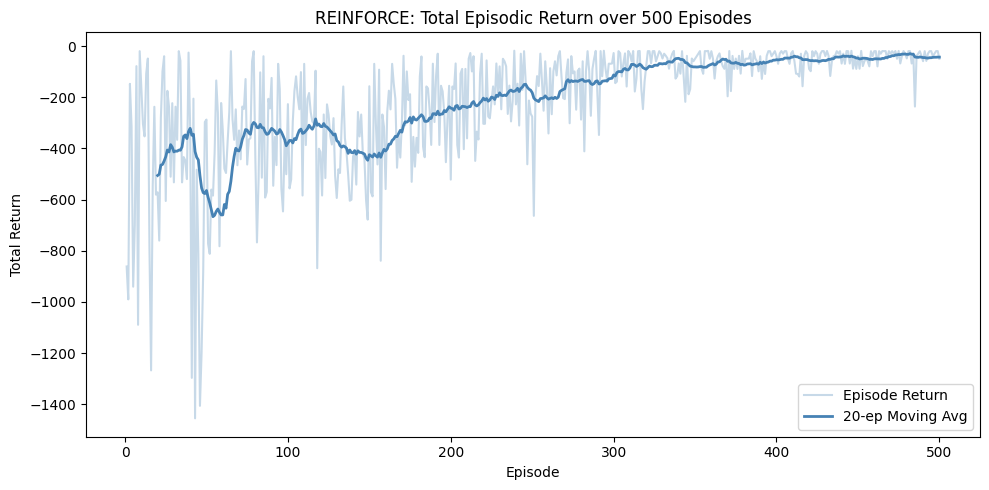


Final 50-episode avg return: -40.5020


In [5]:
# ── Plot: Total Episodic Return over 500 Episodes ─────────────────────────
window_size = 20
smoothed = np.convolve(episode_returns, np.ones(window_size)/window_size, mode='valid')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, N_EPISODES + 1), episode_returns, alpha=0.3, color='steelblue', label='Episode Return')
ax.plot(range(window_size, N_EPISODES + 1), smoothed, color='steelblue', lw=2, label=f'{window_size}-ep Moving Avg')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Return')
ax.set_title('REINFORCE: Total Episodic Return over 500 Episodes')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal 50-episode avg return: {np.mean(episode_returns[-50:]):.4f}")